In [106]:
import pandas as pd
from google.cloud import bigquery
import os
from mlxtend.frequent_patterns import apriori, association_rules
from scipy.sparse import csr_matrix
import networkx as nx
import matplotlib.pyplot as plt



In [107]:
path_ke_key = os.path.join('..','..', 'bq_key', 'my_dbt_key.json')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = path_ke_key

client = bigquery.Client()

query = """
    SELECT 
      fs.customer_sk,
      dp.english_name,
      dp.product_sk,
      dd.full_date as purchase_date
    FROM `dbt-project-482716.dbt_dataset_global.fact_order_item` foi
    JOIN `dbt-project-482716.dbt_dataset_global.fact_sales` fs
        ON foi.order_id = fs.order_id
    JOIN `dbt-project-482716.dbt_dataset_global.dim_product` dp
        ON foi.product_sk = dp.product_sk 
    JOIN `dbt-project-482716.dbt_dataset_global.dim_date` dd
        ON fs.purchase_date_sk = dd.date_sk 
    WHERE fs.order_status = 'delivered'
"""

In [108]:
df_orders = client.query(query).to_dataframe(create_bqstorage_client=False)
print(df_orders.head())

                        customer_sk             english_name  \
0  e2e288fbe7984538e575b9d5f9839334                    music   
1  d893cd1ce87ac31b05d3598ce41dc98d  fashion_underwear_beach   
2  4eb8b02af07dc47c604f321e60ee3b28  fashion_underwear_beach   
3  4eb8b02af07dc47c604f321e60ee3b28  fashion_underwear_beach   
4  64b5e91e9f10bfd8fe246e5e70a8872f  fashion_underwear_beach   

                         product_sk purchase_date  
0  cf13172ec092b324d5c62dfc192f58c5    2018-06-22  
1  3bd86d6570df7762a7b62f50181f6ce8    2017-06-22  
2  495e8e4f4b438385b6aee014f2edc842    2018-05-02  
3  495e8e4f4b438385b6aee014f2edc842    2018-05-02  
4  495e8e4f4b438385b6aee014f2edc842    2018-06-15  


In [109]:
df_orders['english_name'].value_counts()

english_name
bed_bath_table               10953
health_beauty                 9465
sports_leisure                8431
furniture_decor               8160
computers_accessories         7644
                             ...  
arts_and_craftmanship           24
cds_dvds_musicals               14
la_cuisine                      14
fashion_childrens_clothes        7
security_and_services            2
Name: count, Length: 71, dtype: int64

<H1>Customer-Based Association</H1>

In [119]:
basket_customer = (df_orders.groupby(['customer_sk', 'english_name'])['product_sk']
                   .count().unstack().reset_index().fillna(0)
                   .set_index('customer_sk'))

basket_customer_sets = basket_customer.map(lambda x: x > 0).astype(bool)

frequent_itemsets = apriori(basket_customer_sets, min_support=0.0005, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

top_rules = rules.sort_values('lift', ascending=False).head(10)
print(f"Ditemukan {len(top_rules)} aturan asosiasi!")

Ditemukan 2 aturan asosiasi!


In [120]:
basket_sparse = csr_matrix(basket_sets.values)

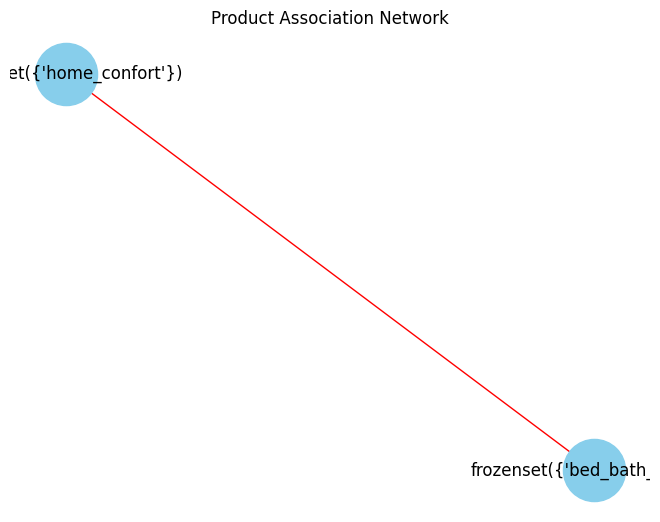

In [121]:
G = nx.from_pandas_edgelist(top_rules, source='antecedents', target='consequents')
nx.draw(G, with_labels=True, node_color='skyblue', node_size=2000, edge_color='red')
plt.title("Product Association Network")
plt.show()

In [122]:
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

        antecedents       consequents   support  confidence      lift
0    (home_confort)  (bed_bath_table)  0.000586    0.138107  1.411722
1  (bed_bath_table)    (home_confort)  0.000586    0.005995  1.411722


In [123]:
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top_rules['consequents'] = top_rules['consequents'].apply(lambda x: ', '.join(list(x)))

top_rules['antecedents'] = top_rules['antecedents'].str.replace(r'\(.*?\)', '', regex=True).str.strip()
top_rules['consequents'] = top_rules['consequents'].str.replace(r'\(.*?\)', '', regex=True).str.strip()

print(top_rules[['antecedents', 'consequents']].head())

      antecedents     consequents
0    home_confort  bed_bath_table
1  bed_bath_table    home_confort


In [124]:
top_rules.to_csv('product_recomendation.csv', index=False)

<H1>Sequential Next Based</H1>

<H2>Product Based</H2>

In [125]:
df_sorted = df_orders.sort_values(['customer_sk', 'purchase_date'])

df_sorted['next_category'] = df_sorted.groupby('customer_sk')['english_name'].shift(-1)

next_best_action = df_sorted.dropna(subset=['next_category']) \
    .groupby(['english_name', 'next_category']).size() \
    .reset_index(name='pair_count') \
    .sort_values('pair_count', ascending=False)

print("Top 5 Category Pairs (Purchase Order):")
print(next_best_action.head(5))

Top 5 Category Pairs (Purchase Order):
              english_name          next_category  pair_count
382        furniture_decor        furniture_decor        1980
86          bed_bath_table         bed_bath_table        1933
150  computers_accessories  computers_accessories        1239
522             housewares             housewares        1110
684         sports_leisure         sports_leisure        1082


In [126]:
next_best_action

,english_name,next_category,pair_count
382,furniture_decor,furniture_decor,1980
86,bed_bath_table,bed_bath_table,1933
150,computers_accessories,computers_accessories,1239
522,housewares,housewares,1110
684,sports_leisure,sports_leisure,1082
...,...,...,...
417,furniture_mattress_and_upholstery,bed_bath_table,1
416,furniture_mattress_and_upholstery,baby,1
414,furniture_living_room,sports_leisure,1
412,furniture_living_room,home_construction,1


In [127]:
next_best_action_diffcat = next_best_action[next_best_action['english_name']!=next_best_action['next_category']]

In [128]:
print("Top 5 Category Pairs (Purchase Order) Based on Not the Same Product Purchase:")
print(next_best_action_diffcat.head(5))

Top 5 Category Pairs (Purchase Order) Based on Not the Same Product Purchase:
        english_name    next_category  pair_count
96    bed_bath_table  furniture_decor         128
488     home_confort   bed_bath_table          50
390  furniture_decor       housewares          46
103   bed_bath_table       housewares          43
384  furniture_decor     garden_tools          32


In [129]:
next_best_action_diffcat

,english_name,next_category,pair_count
96,bed_bath_table,furniture_decor,128
488,home_confort,bed_bath_table,50
390,furniture_decor,housewares,46
103,bed_bath_table,housewares,43
384,furniture_decor,garden_tools,32
...,...,...,...
417,furniture_mattress_and_upholstery,bed_bath_table,1
416,furniture_mattress_and_upholstery,baby,1
414,furniture_living_room,sports_leisure,1
412,furniture_living_room,home_construction,1


In [130]:
next_best_action.to_csv('product_sequential_best_action.csv', index=False)

<H2>Grouping Product Based</H2>

In [131]:
df_orders['english_name'].unique()

array(['music', 'fashion_underwear_beach', 'signaling_and_security',
       'art', 'christmas_supplies', 'books_general_interest',
       'fixed_telephony', 'drinks', 'food_drink',
       'costruction_tools_tools', 'cine_photo', 'furniture_bedroom',
       'home_confort', 'party_supplies', 'costruction_tools_garden',
       'construction_tools_safety', 'dvds_blu_ray',
       'kitchen_dining_laundry_garden_furniture', 'arts_and_craftmanship',
       'books_technical', 'market_place', 'food',
       'small_appliances_home_oven_and_coffee', 'air_conditioning',
       'construction_tools_lights', 'home_comfort_2',
       'agro_industry_and_commerce', 'home_appliances_2',
       'furniture_living_room', 'tablets_printing_image', 'audio',
       'fashion_male_clothing', 'flowers', 'books_imported',
       'fashio_female_clothing', 'la_cuisine', 'fashion_sport',
       'diapers_and_hygiene', 'fashion_shoes',
       'industry_commerce_and_business', 'computers',
       'fashion_childrens_cloth

In [132]:
category_mapping = {
    # HOME & LIVING
    'home_confort': 'HOME_LIVING', 'home_comfort_2': 'HOME_LIVING', 'furniture_decor': 'HOME_LIVING',
    'bed_bath_table': 'HOME_LIVING', 'housewares': 'HOME_LIVING', 'furniture_living_room': 'HOME_LIVING',
    'furniture_bedroom': 'HOME_LIVING', 'furniture_mattress_and_upholstery': 'HOME_LIVING',
    'kitchen_dining_laundry_garden_furniture': 'HOME_LIVING', 'office_furniture': 'HOME_LIVING',
    
    # TECH & ELECTRONICS
    'telephony': 'TECH', 'fixed_telephony': 'TECH', 'computers_accessories': 'TECH', 
    'computers': 'TECH', 'electronics': 'TECH', 'consoles_games': 'TECH', 
    'audio': 'TECH', 'tablets_printing_image': 'TECH',
    
    # FASHION & ACCESSORIES
    'fashion_bags_accessories': 'FASHION', 'fashion_shoes': 'FASHION', 
    'fashion_male_clothing': 'FASHION', 'fashio_female_clothing': 'FASHION',
    'fashion_sport': 'FASHION', 'fashion_underwear_beach': 'FASHION', 
    'fashion_childrens_clothes': 'FASHION', 'watches_gifts': 'FASHION',
    
    # HEALTH & BEAUTY
    'health_beauty': 'HEALTH_BEAUTY', 'perfumery': 'HEALTH_BEAUTY', 
    'diapers_and_hygiene': 'HEALTH_BEAUTY', 'baby': 'HEALTH_BEAUTY',
    
    # CONSTRUCTION & TOOLS
    'construction_tools_construction': 'CONSTRUCTION', 'costruction_tools_tools': 'CONSTRUCTION',
    'construction_tools_lights': 'CONSTRUCTION', 'costruction_tools_safety': 'CONSTRUCTION',
    'home_construction': 'CONSTRUCTION', 'costruction_tools_garden': 'CONSTRUCTION',
    'garden_tools': 'CONSTRUCTION',
    
    # LIFESTYLE & HOBBY
    'sports_leisure': 'LIFESTYLE', 'toys': 'LIFESTYLE', 'cool_stuff': 'LIFESTYLE',
    'musical_instruments': 'LIFESTYLE', 'art': 'LIFESTYLE', 'books_general_interest': 'LIFESTYLE',
    'books_technical': 'LIFESTYLE', 'books_imported': 'LIFESTYLE', 'pet_shop': 'LIFESTYLE',
    'cine_photo': 'LIFESTYLE', 'dvds_blu_ray': 'LIFESTYLE', 'cds_dvds_musicals': 'LIFESTYLE',
    'music': 'LIFESTYLE', 'arts_and_craftmanship': 'LIFESTYLE', 'party_supplies': 'LIFESTYLE',
    'christmas_supplies': 'LIFESTYLE'
}

df_orders['super_category'] = df_orders['english_name'].map(category_mapping).fillna('OTHERS')

In [133]:
basket_customer = (df_orders.groupby(['customer_sk', 'super_category'])['product_sk']
                   .count().unstack().reset_index().fillna(0)
                   .set_index('customer_sk'))

basket_customer_sets = basket_customer.map(lambda x: x > 0).astype(bool)

frequent_itemsets = apriori(basket_customer_sets, min_support=0.0001, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

top_rules = rules.sort_values('lift', ascending=False).head(10)
print(f"Ditemukan {len(top_rules)} aturan asosiasi!")

Ditemukan 0 aturan asosiasi!


In [134]:
df_sorted = df_orders.sort_values(['customer_sk', 'purchase_date'])

df_sorted['next_category'] = df_sorted.groupby('customer_sk')['super_category'].shift(-1)

next_best_action = df_sorted.dropna(subset=['next_category']) \
    .groupby(['super_category', 'next_category']).size() \
    .reset_index(name='pair_count') \
    .sort_values('pair_count', ascending=False)

print("Top 5 Super Category Pairs (Purchase Order):")
print(next_best_action.head(5))

Top 5 Super Category Pairs (Purchase Order):
   super_category  next_category  pair_count
24    HOME_LIVING    HOME_LIVING        6024
48           TECH           TECH        2048
32      LIFESTYLE      LIFESTYLE        1986
16  HEALTH_BEAUTY  HEALTH_BEAUTY        1492
40         OTHERS         OTHERS        1387


In [135]:
next_best_action

,super_category,next_category,pair_count
24,HOME_LIVING,HOME_LIVING,6024
48,TECH,TECH,2048
32,LIFESTYLE,LIFESTYLE,1986
16,HEALTH_BEAUTY,HEALTH_BEAUTY,1492
40,OTHERS,OTHERS,1387
0,CONSTRUCTION,CONSTRUCTION,1279
8,FASHION,FASHION,744
18,HEALTH_BEAUTY,LIFESTYLE,113
25,HOME_LIVING,LIFESTYLE,112
38,OTHERS,HOME_LIVING,99


In [136]:
next_best_action_diffcat = next_best_action[next_best_action['super_category']!=next_best_action['next_category']]

In [137]:
print("Top 5 Super Category Pairs (Purchase Order) Based on Not the Same Product Purchase:")
print(next_best_action_diffcat.head(5))

Top 5 Super Category Pairs (Purchase Order) Based on Not the Same Product Purchase:
   super_category  next_category  pair_count
18  HEALTH_BEAUTY      LIFESTYLE         113
25    HOME_LIVING      LIFESTYLE         112
38         OTHERS    HOME_LIVING          99
23    HOME_LIVING  HEALTH_BEAUTY          87
17  HEALTH_BEAUTY    HOME_LIVING          87


In [138]:
next_best_action_diffcat

,super_category,next_category,pair_count
18,HEALTH_BEAUTY,LIFESTYLE,113
25,HOME_LIVING,LIFESTYLE,112
38,OTHERS,HOME_LIVING,99
23,HOME_LIVING,HEALTH_BEAUTY,87
17,HEALTH_BEAUTY,HOME_LIVING,87
39,OTHERS,LIFESTYLE,83
31,LIFESTYLE,HOME_LIVING,80
3,CONSTRUCTION,HOME_LIVING,76
21,HOME_LIVING,CONSTRUCTION,73
26,HOME_LIVING,OTHERS,69


In [139]:
next_best_action.to_csv('product_super_category_sequential_best_action.csv', index=False)

In [142]:
df_unique_categories = df_orders[['english_name', 'super_category']].drop_duplicates().reset_index(drop=True)

In [143]:
df_unique_categories.to_csv('super_categories.csv', index=False)